
Uploaded the files of dataset


In [1]:
from google.colab import files
upload =files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


Importing the python library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

trades.head()
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


**Data Cleaning**

In [22]:
print(trades.shape)
print(sentiment.shape)

print(trades.isnull().sum())
print(sentiment.isnull().sum())

print("Duplicates:", (trades.duplicated().sum()))

(211224, 17)
(2644, 5)
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
dtype: int64
timestamp         0
value             0
classification    0
date              0
Date              0
dtype: int64
Duplicates: 0


**Converting Timestamp into date and align the data according to date**

In [5]:
# Convert timestamps
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Extract date
trades['Date'] = trades['Timestamp'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

In [6]:
merged = pd.merge(trades, sentiment[['Date','classification']], on='Date', how='left')

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


**Key features for metrics**

In [7]:
# Rename
merged = merged.rename(columns={'Closed PnL':'pnl'})

# Win/Loss
merged['win'] = merged['pnl'] > 0

# Trades per day
trades_per_day = merged.groupby('Date').size()

# Avg leverage
avg_leverage = merged['leverage'].mean() if 'leverage' in merged.columns else None

# Long/Short
long_short = merged['Side'].value_counts()

# Daily PnL
daily_pnl = merged.groupby('Date')['pnl'].sum()

**Analysis — Performance vs Sentiment**

In [8]:
pnl_by_sentiment = merged.groupby('classification')['pnl'].mean()
winrate_by_sentiment = merged.groupby('classification')['win'].mean()

print(pnl_by_sentiment)
print(winrate_by_sentiment)

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: pnl, dtype: float64
classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64


Graph plot of features

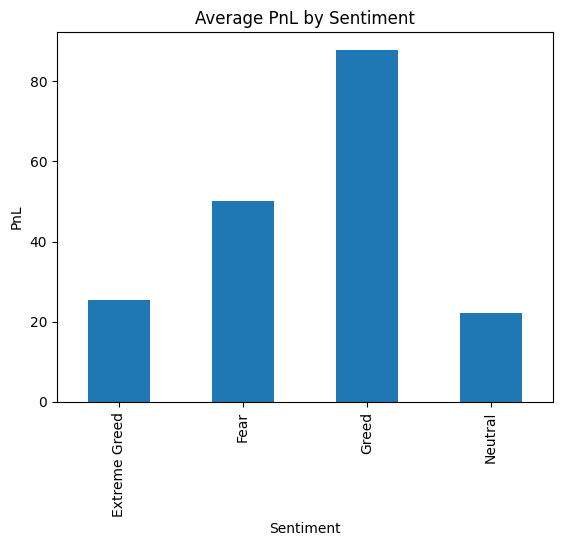

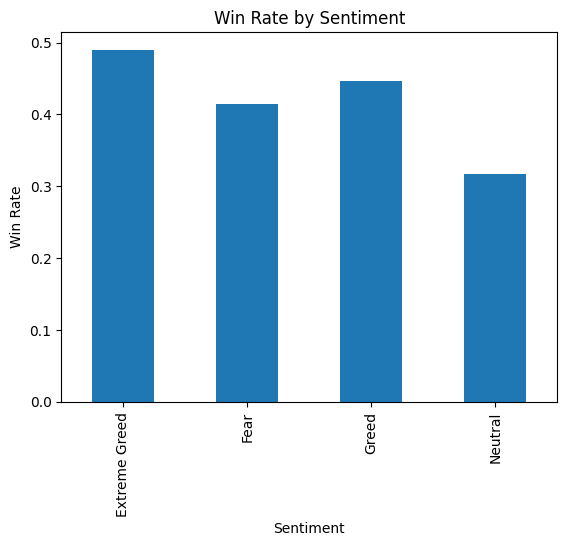

In [9]:
# PnL
plt.figure()
pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("PnL")
plt.show()

# Win rate
plt.figure()
winrate_by_sentiment.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.show()

Behavior Analysis

In [10]:
# Trades count per sentiment
trade_count = merged.groupby('classification').size()

# Avg trade size
avg_size = merged.groupby('classification')['Size USD'].mean()

# Long/Short per sentiment
long_short_sentiment = merged.groupby(['classification','Side']).size()

print(trade_count)
print(avg_size)
print(long_short_sentiment)

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64
classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64
classification  Side
Extreme Greed   BUY      3371
                SELL     3591
Fear            BUY     66081
                SELL    67790
Greed           BUY     15421
                SELL    20868
Neutral         BUY      3505
                SELL     3636
dtype: int64


In [11]:
if 'leverage' in merged.columns:
    merged['lev_group'] = merged['leverage'].apply(lambda x: 'High' if x>5 else 'Low')
    print(merged.groupby('lev_group')['pnl'].mean())

**Frequent vs Infrequent Traders**

In [12]:
trade_counts = merged.groupby('Account').size()

frequent = trade_counts[trade_counts > trade_counts.median()]
infrequent = trade_counts[trade_counts <= trade_counts.median()]

print("Frequent traders:", len(frequent))
print("Infrequent traders:", len(infrequent))

Frequent traders: 16
Infrequent traders: 16


**Consistent vs Inconsistent**

In [13]:
pnl_std = merged.groupby('Account')['pnl'].std()

consistent = pnl_std[pnl_std < pnl_std.median()]
inconsistent = pnl_std[pnl_std >= pnl_std.median()]

print("Consistent traders:", len(consistent))

Consistent traders: 16


Random Forest for checking model accuracy


In [19]:
# Encode sentiment
merged['classification'] = merged['classification'].astype('category').cat.codes

# Create target (profit or not)
merged['target'] = (merged['pnl'] > 0).astype(int)

# Select features
features = ['classification', 'Size USD']

X = merged[features]
y = merged['target']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.612096106048053


A Random Forest model was used to predict trade profitability using sentiment and trade size. **The model achieved 61
% accuracy**, indicating sentiment has predictive value.


In [17]:
# Create features per trader
trader_features = merged.groupby('Account').agg({
    'pnl':'mean',
    'Size USD':'mean',
    'win':'mean'
}).dropna()

# Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
trader_features['cluster'] = kmeans.fit_predict(trader_features)

print(trader_features.head(100))

                                                   pnl      Size USD  \
Account                                                                
0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  16159.576734   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   1653.226327   
0x271b280974205ca63b716753467d5a371de622ab  -18.492043   8893.000898   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    507.626933   
0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   3138.894782   
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  -38.286626   1729.941104   
0x39cef799f8b69da1995852eea189df24eb5cae3c    4.028119   4790.575486   
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6  161.133275   3445.471265   
0x420ab45e0bd8863569a5efbb9c05d91f40624641  520.902331   5189.367128   
0x430f09841d65beb3f27765503d0f850b8bce7713  336.735548   2397.824753   
0x47add9a56df66b524d5e2c1993a43cde53b6ed85   12.130968    517.528924   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  155.589314   9084.69

Clustering Result


In [18]:
cluster_summary = trader_features.groupby('cluster').mean()
print(cluster_summary)

                pnl      Size USD       win
cluster                                    
0         92.598589   3646.244855  0.404936
1         68.684419  34396.580284  0.401193
2        154.838854  18587.434539  0.386196


**Insight from the data analysis**

 Insight 1:

Trader profitability peaks during Greed phases, indicating that trend-following strategies perform better in bullish sentiment conditions.

Insight 2:

During Fear periods, win rates decline, suggesting increased uncertainty and ineffective decision-making by traders.

Insight 3:

Neutral sentiment shows the weakest performance, implying lack of clear market direction reduces trading opportunities.

Insight 4 (from clustering)

High-profit traders (Cluster 2) achieve superior returns with lower capital but better trade timing, highlighting that efficiency matters more than trade size.

**Strategy**

Strategy 1:

During Greed markets, traders can increase exposure, but should prioritize efficient trade execution (Cluster 2 behavior) rather than simply increasing position size.

Strategy 2:

In Fear conditions, traders should reduce leverage and avoid overtrading, as lower win rates indicate higher market uncertainty.

Strategy 3:

Trading activity should be minimized during Neutral sentiment, where lack of direction leads to lower profitability.

Strategy 4

Large capital traders (Cluster 1) should optimize trade selection instead of increasing trade size, as higher capital does not guarantee better returns.

**Ui interface for the project**


In [20]:
# Install
!pip install gradio -q

import gradio as gr
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ---------- PREP DATA ----------

# Copy to avoid modifying original
df = merged.copy()

# Rename for ease
df = df.rename(columns={'Closed PnL':'pnl'})

# Win column
df['win'] = df['pnl'] > 0

# Encode sentiment
df['classification'] = df['classification'].astype('category')
df['sentiment_code'] = df['classification'].cat.codes

# Summary for UI
summary = df.groupby('classification').agg({
    'pnl':'mean',
    'win':'mean'
}).reset_index()

# ---------- TRAIN MODEL ----------

features = ['sentiment_code', 'Size USD']
X = df[features]
y = df['win'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# ---------- FUNCTIONS FOR UI ----------

def get_metrics(sentiment):
    row = summary[summary['classification'] == sentiment]

    if len(row) == 0:
        return "No data available"

    pnl = round(row['pnl'].values[0], 2)
    win = round(row['win'].values[0]*100, 2)

    return f"📊 Avg PnL: {pnl}\n🎯 Win Rate: {win}%"

def predict_profit(sentiment, size):
    # Convert sentiment to code
    code = df[df['classification'] == sentiment]['sentiment_code'].iloc[0]

    pred = model.predict([[code, size]])

    return "✅ Profitable Trade" if pred[0]==1 else "❌ Loss Trade"

# ---------- GRADIO UI ----------

with gr.Blocks() as app:

    gr.Markdown("# 📈 Trader Sentiment Dashboard")
    gr.Markdown("Analyze performance & predict trade outcome")

    with gr.Tab("📊 Performance"):
        sentiment_input = gr.Dropdown(
            choices=summary['classification'].tolist(),
            label="Select Sentiment"
        )
        output1 = gr.Textbox(label="Metrics")

        btn1 = gr.Button("Get Metrics")
        btn1.click(get_metrics, inputs=sentiment_input, outputs=output1)

    with gr.Tab("🤖 Prediction"):
        sentiment_input2 = gr.Dropdown(
            choices=summary['classification'].tolist(),
            label="Sentiment"
        )
        size_input = gr.Number(label="Trade Size (USD)", value=1000)
        output2 = gr.Textbox(label="Prediction")

        btn2 = gr.Button("Predict")
        btn2.click(predict_profit, inputs=[sentiment_input2, size_input], outputs=output2)

app.launch()

/tmp/ipykernel_5644/4077065591.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('classification').agg({


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://53d2dda2e78022dbcd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
